In [4]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

csv_path = csv_path = 'img_align_celeba_small/list_attr_celeba_small.csv'
df = pd.read_csv(csv_path)

attributes = ['Attractive', 'Heavy_Makeup', 'Male', 'Pointy_Nose', 'Smiling', 'Young']

for attr in attributes:
    df[attr] = df[attr].replace(-1, 0)

train_df = df[df['Eval'] == 0].copy()
val_df = df[df['Eval'] == 1].copy()

print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(val_df)}")

train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

image_dir = 'img_align_celeba_small/img_align_celeba_small/'

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='image_id',
    y_col=attributes,
    target_size=(128, 128),
    batch_size=32,
    class_mode='raw'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir,
    x_col='image_id',
    y_col=attributes,
    target_size=(128, 128),
    batch_size=32,
    class_mode='raw'
)

Training images: 49999
Validation images: 10001
Found 49999 validated image filenames.
Found 10001 validated image filenames.


In [5]:
#Baseline single task CNN
import tensorflow as tf
from keras.models import Sequential, Model
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, GlobalAveragePooling2D, Input

tf.keras.backend.clear_session()

model_baseline = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='sigmoid') # 6 nodes for 6 attributes
])

model_baseline.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Baseline Model Parameters:", model_baseline.count_params())

history_baseline = model_baseline.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Baseline Model Parameters: 127814
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 188s 120ms/step - accuracy: 0.1139 - loss: 0.5948 - val_accuracy: 0.2349 - val_loss: 0.5209
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 159s 102ms/step - accuracy: 0.2558 - loss: 0.4842 - val_accuracy: 0.2754 - val_loss: 0.4448
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 127s 81ms/step - accuracy: 0.2882 - loss: 0.4252 - val_accuracy: 0.3168 - val_loss: 0.3867
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 0.3015 - loss: 0.3841 - val_accuracy: 0.3236 - val_loss: 0.3572
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1040s 666ms/step - accuracy: 0.3048 - loss: 0.3628 - val_accuracy: 0.3470 - val_loss: 0.3585
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 85ms/step - accuracy: 0.3074 - loss: 0.3471 - val_accuracy: 0.3372 - val_loss: 0.3323
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 139s 89ms/step - accuracy: 0.3096 - loss: 0.3373 - val_accuracy: 0.3368 - val_loss: 0.3273
Epoch 8/10
1563/1563 ━━━━━━━━━

In [7]:
#Multi-task model
import tensorflow as tf
from keras.models import Model
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, GlobalAveragePooling2D, Input

tf.keras.backend.clear_session()

def multitask_generator(generator):
    while True:
        x, y = next(generator)
        y_dict = {
            'Attractive': y[:, 0],
            'Heavy_Makeup': y[:, 1],
            'Male': y[:, 2],
            'Pointy_Nose': y[:, 3],
            'Smiling': y[:, 4],
            'Young': y[:, 5]
        }
        yield x, y_dict

inputs = Input(shape=(128, 128, 3))

x = Conv2D(32, (3, 3), activation='relu')(inputs)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = GlobalAveragePooling2D()(x)
shared_features = Dense(128, activation='relu')(x)

outputs = []
for attr in attributes:
    head = Dense(64, activation='relu')(shared_features)
    head = Dropout(0.3)(head)
    out = Dense(1, activation='sigmoid', name=attr)(head)
    outputs.append(out)

model_multitask = Model(inputs, outputs)

model_multitask.compile(
    optimizer='adam',
    loss={attr: 'binary_crossentropy' for attr in attributes},
    metrics={attr: 'accuracy' for attr in attributes}
)

print("Multi-Task Model Parameters:", model_multitask.count_params())

history_multitask = model_multitask.fit(
    multitask_generator(train_generator),
    steps_per_epoch=len(train_generator),
    validation_data=multitask_generator(val_generator),
    validation_steps=len(val_generator),
    epochs=10
)

Multi-Task Model Parameters: 77638
Epoch 1/10


C:\Users\Shiraz\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a generator. The generator is expected to yield already-shuffled data.
  self.data_adapter = data_adapters.get_data_adapter(


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 112s 70ms/step - Attractive_accuracy: 0.5790 - Attractive_loss: 0.6720 - Heavy_Makeup_accuracy: 0.6378 - Heavy_Makeup_loss: 0.6356 - Male_accuracy: 0.6288 - Male_loss: 0.6414 - Pointy_Nose_accuracy: 0.7246 - Pointy_Nose_loss: 0.5863 - Smiling_accuracy: 0.5423 - Smiling_loss: 0.6857 - Young_accuracy: 0.7805 - Young_loss: 0.5266 - loss: 3.7478 - val_Attractive_accuracy: 0.6228 - val_Attractive_loss: 0.6479 - val_Heavy_Makeup_accuracy: 0.6714 - val_Heavy_Makeup_loss: 0.6047 - val_Male_accuracy: 0.6731 - val_Male_loss: 0.5941 - val_Pointy_Nose_accuracy: 0.7202 - val_Pointy_Nose_loss: 0.5818 - val_Smiling_accuracy: 0.5630 - val_Smiling_loss: 0.6816 - val_Young_accuracy: 0.7744 - val_Young_loss: 0.5164 - val_loss: 3.6265
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 105s 67ms/step - Attractive_accuracy: 0.6603 - Attractive_loss: 0.6187 - Heavy_Makeup_accuracy: 0.7138 - Heavy_Makeup_loss: 0.5587 - Male_accuracy: 0.7225 - Male_loss: 0.5459 - Pointy_Nose_accuracy: 0.7

In [8]:
from keras.applications import MobileNetV2

tf.keras.backend.clear_session()

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

inputs = Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(6, activation='sigmoid')(x)

model_transfer = Model(inputs, outputs)
model_transfer.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Transfer Learning Model Parameters:", model_transfer.count_params())

history_transfer = model_transfer.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Transfer Learning Model Parameters: 2587462
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 85ms/step - accuracy: 0.2840 - loss: 0.4417 - val_accuracy: 0.3074 - val_loss: 0.4006
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.2899 - loss: 0.4130 - val_accuracy: 0.2988 - val_loss: 0.3899
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.2930 - loss: 0.4043 - val_accuracy: 0.3135 - val_loss: 0.3913
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 88ms/step - accuracy: 0.2930 - loss: 0.4005 - val_accuracy: 0.3042 - val_loss: 0.3853
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.2931 - loss: 0.3968 - val_accuracy: 0.3197 - val_loss: 0.3844
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 139s 89ms/step - accuracy: 0.2975 - loss: 0.3934 - val_accuracy: 0.2955 - val_loss: 0.3837
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 147s 94ms/step - accuracy: 0.3010 - loss: 0.3912 - val_accuracy: 0.3085 - val_loss: 0.3825
Epoch 8/10
1563/1563 ━━━━

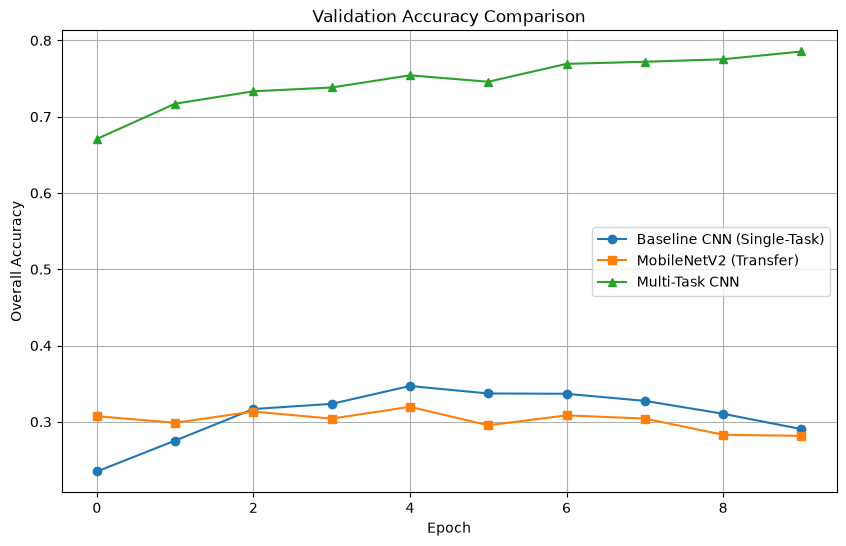


--- FAIRNESS AUDIT ---
Target predicting: 'Male'
Found 10001 validated image filenames.
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step

Subgroup: Heavy_Makeup
  Accuracy when Heavy_Makeup = 1: 98.84%
  Accuracy when Heavy_Makeup = 0: 87.62%
  Fairness Gap: 11.22%

Subgroup: Young
  Accuracy when Young = 1: 91.93%
  Accuracy when Young = 0: 92.02%
  Fairness Gap: 0.09%

Subgroup: Smiling
  Accuracy when Smiling = 1: 93.77%
  Accuracy when Smiling = 0: 90.27%
  Fairness Gap: 3.50%

Subgroup: Attractive
  Accuracy when Attractive = 1: 95.17%
  Accuracy when Attractive = 0: 88.66%
  Fairness Gap: 6.52%


In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

plt.plot(history_baseline.history['val_accuracy'], label='Baseline CNN (Single-Task)', marker='o')
plt.plot(history_transfer.history['val_accuracy'], label='MobileNetV2 (Transfer)', marker='s')

mt_val_accs = [history_multitask.history[f'val_{attr}_accuracy'] for attr in attributes]
avg_mt_val_acc = np.mean(mt_val_accs, axis=0)
plt.plot(avg_mt_val_acc, label='Multi-Task CNN', marker='^')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Overall Accuracy')
plt.legend()
plt.grid(True)
plt.show()


print("\n--- FAIRNESS AUDIT ---")
print("Target predicting: 'Male'")

val_gen_eval = val_datagen.flow_from_dataframe(
    dataframe=val_df, directory=image_dir, x_col='image_id', y_col=attributes,
    target_size=(128, 128), batch_size=32, class_mode='raw', shuffle=False
)

preds = model_transfer.predict(val_gen_eval)

target_idx = attributes.index('Male')
pred_male = (preds[:, target_idx] > 0.5).astype(int)
true_male = val_df['Male'].values

subgroups_to_test = ['Heavy_Makeup', 'Young', 'Smiling', 'Attractive']

for subgroup in subgroups_to_test:
    subgroup_true = val_df[subgroup].values

    mask_1 = (subgroup_true == 1)
    acc_1 = np.mean(pred_male[mask_1] == true_male[mask_1])

    mask_0 = (subgroup_true == 0)
    acc_0 = np.mean(pred_male[mask_0] == true_male[mask_0])

    print(f"\nSubgroup: {subgroup}")
    print(f"  Accuracy when {subgroup} = 1: {acc_1:.2%}")
    print(f"  Accuracy when {subgroup} = 0: {acc_0:.2%}")
    print(f"  Fairness Gap: {abs(acc_1 - acc_0):.2%}")